In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent / "src"))
import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance


panel_data_path = config.PROJECT_ROOT/ "data" / "panel_data_imputed.csv"
panel_data = pd.read_csv(panel_data_path)

The initial training and validation split was used for feature selection. For hyperparameter tuning, the training and validation years were combined and time-based cross-validation was applied within combined training set. Testing and model evaluation was performed on a held-out test set, containing panel data from 2024.

Feature selection decisions were made to maximise accuracy on validation set. Accuracy chosen as evaluation metric on assumption that cost of missing a churner is the same as cost of false positive.  While intervention costs are typically lower than customer lifetime value (CLV), the effectiveness of retention actions is uncertain and may require repeated attempts. In the absence of detailed business data, accuracy was used as evaluation metric assuming equal misclassification costs. The test dataset is fairly balanced (52:48), as is the training data, with the exception of 2020 and 2021, likely due to the impact of COVID. However, for most years, the balanced class sizes make accuracy an interpretable metric. With information about CLV, cost of interventions, conversion rate of interventions, a profit-based evaluation metric could be used instead.


Excluding 2020 and 2021 from training data was considered, but not done. This could be done with the intention of maximising model performance in "normal" times. However, there was negligible performance difference on the validation set between models trained on entire train set and models trained excluding 2020 and 2021 from the training data. Including 2020 and 2021 in the training data is therefore not expected to hurt model accuracy, and may make the model more resistant to shocks.


In [2]:
#WeightClassKg already encoded in WeightClassKgCode

panel = panel_data.drop(columns = ['Name', 'WeightClassKg'])
train = panel.loc[panel['Year']<=2022]
validate = panel.loc[panel['Year']==2023]
test = panel.loc[panel['Year']>2023]

#train/validate/test split (75/12/13)
train_X = train.drop(columns = 'Churns')
train_y = train['Churns']
validate_X = validate.drop(columns = 'Churns')
validate_y = validate['Churns']
test_X = test.drop(columns = 'Churns')
test_y = test['Churns']

In [3]:
#will be using performance on validation set for feature selection

def evaluate_model(classifier, X_val, y_val):
    preds = classifier.predict(X_val)
    probs = classifier.predict_proba(X_val)[:, 1]
    return {
        "f1":        f1_score(y_val, preds),
        "recall":    recall_score(y_val, preds),
        "accuracy":  accuracy_score(y_val, preds),
        "precision": precision_score(y_val, preds),
        "roc_auc":   roc_auc_score(y_val, probs)
        
    }

Two sets of features capturing lifter improvement over time were constructed in `notebooks/02_data_transformation.ipynb`: one based on absolute (raw) improvement and one based on percentage improvement. Model performance was then evaluated on the validation set using (i) all features, (ii) a feature set excluding raw improvement features, and (iii) a feature set excluding percentage-based features. This informed the feature selection. Performance differences between the feature sets were negligible. To reduce complexity, only absolute improvement features were kept in the feature set.

Permutation importance was used to assess feature relevance, and features with negative importance were removed.


In [4]:
train_raw_X = train_X.drop(columns = ['PercentageImprovementGradientWithinYear', 'PercentageImprovementGradientTwoMeets', 
                                           'PercentageImprovementGradientBetweenYears', 'ImprovementAccelerationForPercentage'])

validate_raw_X = validate_X.drop(columns = ['PercentageImprovementGradientWithinYear', 'PercentageImprovementGradientTwoMeets', 
                                           'PercentageImprovementGradientBetweenYears', 'ImprovementAccelerationForPercentage'])


clf_raw = HistGradientBoostingClassifier(
    random_state=42,
    categorical_features = ['Sex']
)
clf_raw.fit(train_raw_X, train_y)


result = permutation_importance(clf_raw, validate_raw_X, validate_y, n_repeats=10, random_state=42)

feature_importance_df = pd.DataFrame({
    'Feature': validate_raw_X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False, ignore_index=True)

perm_feats = feature_importance_df.loc[feature_importance_df['Importance']>0, 'Feature'].to_list()
train_perm_X = train_X[perm_feats]
validate_perm_X = validate_X[perm_feats]
clf_perm_feats = HistGradientBoostingClassifier(
    random_state=42,
    categorical_features = ['Sex']
)
clf_perm_feats.fit(train_perm_X, train_y)

reduced_feats = feature_importance_df.loc[feature_importance_df['Importance']>0, 'Feature'].to_list()

feature_importance_df

,Feature,Importance
0,TimeSinceLastPBYearEnd,0.036702
1,BestGoodliftOfYear,0.017960
2,ImprovementGradientWithinYear,0.014742
3,Age,0.011384
4,AvgMeetsPerYear,0.009564
5,Sex,0.003141
6,FederationProportion,0.001917
7,NumberOfMeets,0.001844
8,TimeCompetingYearEnd,0.001811
9,ImprovementGradientBetweenYears,0.001469


### Incremental addition of features

Incrementally added features in order of importance as determined by permutation importance and plotted performance on validation set.


In [5]:
results = []

for i in tqdm(range(1,len(reduced_feats))):
    features = reduced_feats[:i]

    train_n_X = train_perm_X[features]
    validate_n_X = validate_perm_X[features]

    categorical_features = ['Sex'] if 'Sex' in features else None
    clf_n = HistGradientBoostingClassifier(
    random_state=42,
    categorical_features = categorical_features
)
    clf_n.fit(train_n_X, train_y)
    
    preds_n = clf_n.predict(validate_n_X)
    probs_n = clf_n.predict_proba(validate_n_X)[:, 1]
    acc_n = accuracy_score(validate_y, preds_n)
    f1_n = f1_score(validate_y, preds_n)
    precision_n = precision_score(validate_y, preds_n)
    recall_n = recall_score(validate_y, preds_n)
    roc_auc_n = roc_auc_score(validate_y, probs_n)

    results.append({'features': features, 
                    'feature_added': features[-1],
                    'accuracy': acc_n,'f1': f1_n, 'precision': precision_n, 
                    'recall':recall_n, 'roc_auc': roc_auc_n})

results_df = pd.DataFrame(results)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:54<00:00,  3.00s/it]


In [6]:
results_df

,features,feature_added,accuracy,f1,precision,recall,roc_auc
0,[TimeSinceLastPBYearEnd],TimeSinceLastPBYearEnd,0.585768,0.671520,0.569057,0.818984,0.617517
1,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear]",BestGoodliftOfYear,0.608635,0.680287,0.588835,0.805370,0.662219
2,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",ImprovementGradientWithinYear,0.636288,0.700577,0.609848,0.823020,0.693089
3,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",Age,0.648278,0.707128,0.620826,0.821298,0.705705
4,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",AvgMeetsPerYear,0.647972,0.710647,0.617902,0.836149,0.711233
5,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",Sex,0.652646,0.711999,0.623092,0.830499,0.711603
6,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",FederationProportion,0.644133,0.689996,0.627690,0.766035,0.683925
7,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",NumberOfMeets,0.645246,0.691683,0.628030,0.769694,0.679614
8,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",TimeCompetingYearEnd,0.644884,0.691555,0.627604,0.770017,0.687033
9,"[TimeSinceLastPBYearEnd, BestGoodliftOfYear, I...",ImprovementGradientBetweenYears,0.645134,0.690779,0.628551,0.766681,0.684813


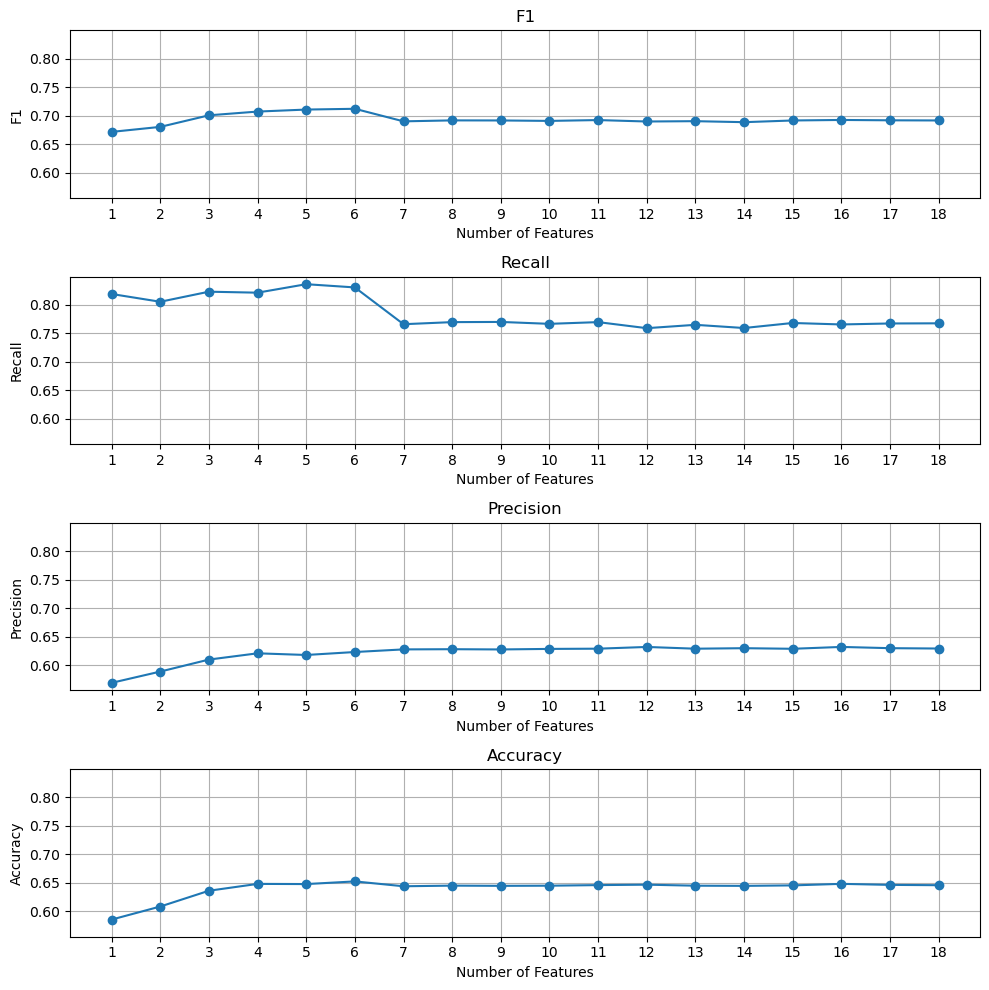

In [7]:
n_features = range(1, len(results_df) + 1)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(10, 10), sharey = True)

ax1.plot(n_features, results_df['f1'], marker='o')
ax1.set_xticks(n_features)
ax1.set_xlabel('Number of Features')
ax1.set_ylabel('F1')
ax1.set_title('F1')
ax1.grid(True)

ax2.plot(n_features, results_df['recall'], marker='o')
ax2.set_xticks(n_features)
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Recall')
ax2.set_title('Recall')
ax2.grid(True)

ax3.plot(n_features, results_df['precision'], marker='o')
ax3.set_xticks(n_features)
ax3.set_xlabel('Number of Features')
ax3.set_ylabel('Precision')
ax3.set_title('Precision')
ax3.grid(True)


ax4.plot(n_features, results_df['accuracy'], marker='o')
ax4.set_xticks(n_features)
ax4.set_xlabel('Number of Features')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy')
ax4.grid(True)

plt.tight_layout()
plt.show()

In the absence of profit-based metrics (cost of retention intervention unknown, intervention conversion rate unknown, value of customer unknown) will optimise for accuracy.  Assumes cost of false positive equals cost of false negative. Balanced class sizes (approx 52/48) so accuracy is interpretable metric. So choose 6 features (index 5 in results_df) as further changes to accuracy past this point on the validation set are noise level. 

In [8]:
features = results_df.loc[5, 'features']

In [9]:
features

['TimeSinceLastPBYearEnd',
 'BestGoodliftOfYear',
 'ImprovementGradientWithinYear',
 'Age',
 'AvgMeetsPerYear',
 'Sex']